# Human Perception of Ethics in Self-Driving Cars: Analysis

This notebook reproduces the analysis for the three research questions. The code is organized into shared setup, helper functions, and one compact section per research question.


In [1]:
from __future__ import annotations

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats


## Setup


In [2]:
DATA_PATH = "../data/processed/final_processed_data.csv"

TEST_CASE_COLUMNS = [
    "How ethically appropriate was the car’s decision in Scenario 1?",
    "How ethically appropriate was the car’s decision in Scenario 2?",
    "How ethically appropriate was the car’s decision in Scenario 3?",
    "How ethically appropriate was the car’s decision in Scenario 4?",
]
TEST_CASE_LABELS = {
    TEST_CASE_COLUMNS[0]: "PP",
    TEST_CASE_COLUMNS[1]: "PF",
    TEST_CASE_COLUMNS[2]: "FP",
    TEST_CASE_COLUMNS[3]: "FF",
}
TEST_CASE_ORDER = ["PP", "PF", "FP", "FF"]

RATING_ORDER = ["Unethical", "Neutral", "Ethical"]
LIKERT_TO_INT = {"Unethical": 1, "Neutral": 2, "Ethical": 3}
RATING_PALETTE = {"Unethical": "#C55E59", "Neutral": "#5E59C5", "Ethical": "#59C55E"}
RATING_PALETTE_LIGHT = {"Unethical": "#E7A7A6", "Neutral": "#A7A6E7", "Ethical": "#A6E7A7"}
RATING_PATTERNS = {"Unethical": ".", "Neutral": "x", "Ethical": "+"}
PLOTLY_RATING_PATTERNS = [RATING_PATTERNS[rating] for rating in RATING_ORDER]

SAFE_ETHICAL_COLUMN = (
    "Considering the scenarios you have been exposed to, do you think that a self-driving car’s safe behavior always aligns with its ethical behavior?"
)

YES_SAFE_ETHICAL = (
    "Yes – Safe behavior and ethical behavior always go hand in hand"
)
NO_SAFE_ETHICAL = (
    "No – A car can be safe but still act unethically (or vice versa)"
)
UNSURE_SAFE_ETHICAL = "Unsure"

SAFE_ETHICAL_ORDER = [
    YES_SAFE_ETHICAL,
    NO_SAFE_ETHICAL,
    UNSURE_SAFE_ETHICAL,
]

SAFE_ETHICAL_BAR_ORDER = [
    NO_SAFE_ETHICAL,
    UNSURE_SAFE_ETHICAL,
    YES_SAFE_ETHICAL,
]

SAFE_ETHICAL_LABELS = {
    YES_SAFE_ETHICAL: "Yes",
    NO_SAFE_ETHICAL: "No",
    UNSURE_SAFE_ETHICAL: "Unsure",
}

SAFE_ETHICAL_PALETTE = {
    YES_SAFE_ETHICAL: "#0072B2",   # blue
    NO_SAFE_ETHICAL: "#D55E00",    # vermillion
    UNSURE_SAFE_ETHICAL: "#BDBDBD",  # gray
}

SAFE_ETHICAL_TEXT_COLOR = {
    YES_SAFE_ETHICAL: "white",
    NO_SAFE_ETHICAL: "white",
    UNSURE_SAFE_ETHICAL: "black",
}

In [3]:
SURVEY = pd.read_csv(
    DATA_PATH,
    keep_default_na=False,
    na_values=[""],
)

print(f"Survey shape: {SURVEY.shape}")
display(SURVEY.head())


Survey shape: (60, 24)


,participant_id,You are a,Education (Currently doing / Completed),Age,What is your field of study or profession ?,Do you have any programming experience?,Do you have any experience with testing any system or application?,Have you ever been in a self-driving car?,"Do you drive motorbikes, cars etc?",What kind of vehicle do you drive ?,...,How ethically appropriate was the car’s decision in Scenario 2?,Please explain why you judged Scenario 2 as you did.,How ethically appropriate was the car’s decision in Scenario 3?,Please explain why you judged Scenario 3 as you did.,How ethically appropriate was the car’s decision in Scenario 4?,Please explain why you judged Scenario 4 as you did.,Did participating in this experiment change the way you think about the ethical behavior of self-driving cars?,Please write in a few words on your experience and suggestions.,"Considering the scenarios you have been exposed to, do you think that a self-driving car’s safe behavior always aligns with its ethical behavior?",Please explain why you answered as you did. Provide also feedback on the survey if relevant for you.
0,P01,Both Student and Professional,Masters,36-40,Computer Science,>5 years,Less than one year,No,No,NaN,...,Unethical,The car is harassing the person. The person wo...,Unethical,The car should have slowed down a bit. The per...,Unethical,"The car nearly hits the pedestrian (unsafe), i...",No – my perception did not change,self-driving cars should drive more defensivel...,No – A car can be safe but still act unethical...,Your introductory example already: a stalled c...
1,P02,Professional,Postdoc,31-35,Math,Less than one year,None,No,Yes,4 wheelers (light-duty vehicles like cars and ...,...,Unethical,the car should stop until pedestrian completel...,Neutral,the pedestrian is not heading towards the road...,Unethical,the car should stop until the pedestrian cross...,Yes – the scenarios made me elaborating a diff...,"I would suggest more complicated scenarios, es...",No – A car can be safe but still act unethical...,safety should be considered not only for the c...
2,P03,Professional,Masters,36-40,"Psychology, Psychotherapy",None,1-2 years,No,No,NaN,...,Unethical,The shown behavior may cause the pedestrian to...,Unethical,It is merely assumed that the pedestrian does ...,Unethical,This is needlessly causing a dangerous situati...,No – my perception did not change,"I perceived the ""unethical"" behavior in these ...",No – A car can be safe but still act unethical...,Feedback for survey: please check my comment i...
3,P04,Student,PhD,41-45,Computer Science,>5 years,>5 years,No,No,NaN,...,Unethical,Moving the car before the pedestrian has compl...,Neutral,The decision was ethical because the pedestria...,Unethical,The decision violates the pedestrian right.,Yes – the scenarios made me elaborating a diff...,I had not thought about it before. This survey...,No – A car can be safe but still act unethical...,The car might drive in a way that it blocks pe...
4,P05,Professional,Postdoc,36-40,Computational Biophysics,1-2 years,None,No,Yes,4 wheelers (light-duty vehicles like cars and ...,...,Unethical,"Personally, I always try to cross as fast as I...",Neutral,I can imagine it could be dangerous if the ped...,Unethical,No explanation is needed!,No – my perception did not change,Good luck with the project and I hope one day ...,Yes – Safe behavior and ethical behavior alway...,I think ethical behavior are always safe. When...


## Shared Helpers


In [4]:
def clean_text_values(series: pd.Series) -> pd.Series:
    """Normalize free-text categorical values without changing missing values."""
    return series.map(lambda value: value.strip() if isinstance(value, str) else value)


def test_case_ratings(df: pd.DataFrame) -> pd.DataFrame:
    """Return the scenario rating columns with publication-friendly short labels."""
    return df.loc[:, TEST_CASE_COLUMNS].rename(columns=TEST_CASE_LABELS).copy()


def likert_scores(ratings_df: pd.DataFrame) -> pd.DataFrame:
    """Convert Likert labels to ordinal scores for non-parametric tests."""
    return ratings_df.apply(lambda series: series.map(LIKERT_TO_INT)).astype("Int64")


def rating_counts_and_percentages(ratings_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compute rating counts and column percentages for each test case."""
    counts = (
        ratings_df.apply(lambda series: series.value_counts())
        .reindex(RATING_ORDER)
        .fillna(0)
        .astype(int)
    )
    percentages = counts.div(counts.sum(axis=0), axis=1).mul(100).round(1)
    return counts, percentages


def prepare_test_case_tables(
    ratings_df: pd.DataFrame,
    rating_order: list[str] = RATING_ORDER,
    test_case_order: list[str] = TEST_CASE_ORDER,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return scores, counts, percentages, and long-form plotting data."""
    scores = likert_scores(ratings_df)
    ordered_ratings = ratings_df.copy()

    for column in ordered_ratings.columns:
        ordered_ratings[column] = pd.Categorical(
            ordered_ratings[column],
            categories=rating_order,
            ordered=True,
        )

    long_df = ordered_ratings.melt(var_name="test_case", value_name="rating").dropna()
    counts = (
        pd.crosstab(long_df["rating"], long_df["test_case"])
        .reindex(index=rating_order, columns=test_case_order, fill_value=0)
        .astype(int)
    )
    percentages = counts.div(counts.sum(axis=0), axis=1).mul(100)
    plot_df = percentages.reset_index().melt(
        id_vars="rating",
        var_name="test_case",
        value_name="pct",
    )
    plot_df["rating"] = pd.Categorical(plot_df["rating"], categories=rating_order, ordered=True)
    return scores, counts, percentages, plot_df


In [5]:
def build_parallel_categories_figure(ratings_df: pd.DataFrame) -> go.Figure:
    fig = px.parallel_categories(
        ratings_df.reset_index(drop=True),
        dimensions=list(ratings_df.columns),
        labels={column: column for column in ratings_df.columns},
    )
    fig.update_layout(margin=dict(l=40, r=40, t=40, b=40))
    return fig


def build_sankey_figure(ratings_df: pd.DataFrame) -> go.Figure:
    link_color_map = {
        "Unethical": "rgba(255, 0, 0, 0.45)",
        "Neutral": "rgba(0, 0, 255, 0.45)",
        "Ethical": "rgba(0, 128, 0, 0.45)",
    }
    node_labels, node_colors, node_index = [], [], {}
    test_cases = list(ratings_df.columns)

    for test_case in test_cases:
        for rating in RATING_ORDER:
            node_index[(test_case, rating)] = len(node_labels)
            node_labels.append(f"{test_case}\n{rating}")
            node_colors.append("rgba(180, 180, 180, 0.6)")

    sources, targets, values, colors, hovertexts = [], [], [], [], []
    participant_count = len(ratings_df)
    for source_case, target_case in zip(test_cases[:-1], test_cases[1:]):
        transition_counts = pd.crosstab(ratings_df[source_case], ratings_df[target_case])
        transition_counts = transition_counts.reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)

        for source_rating in RATING_ORDER:
            for target_rating in RATING_ORDER:
                count = int(transition_counts.loc[source_rating, target_rating])
                if count <= 0:
                    continue
                sources.append(node_index[(source_case, source_rating)])
                targets.append(node_index[(target_case, target_rating)])
                values.append(count)
                colors.append(link_color_map.get(source_rating, "rgba(120, 120, 120, 0.4)"))
                hovertexts.append(
                    f"{source_case} -> {target_case}<br>"
                    f"{source_rating} -> {target_rating}<br>"
                    f"n = {count} ({100.0 * count / participant_count:.1f}%)"
                )

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(label=node_labels, color=node_colors, pad=18, thickness=18),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color=colors,
                    hovertemplate="%{customdata}<extra></extra>",
                    customdata=hovertexts,
                ),
            )
        ]
    )
    fig.update_layout(
        title="Ethical perception flows across test cases (colored by source rating)",
        font_size=12,
        height=520,
        margin=dict(l=20, r=20, t=60, b=20),
    )
    return fig


In [6]:
def split_by_ordinal_median(
    df: pd.DataFrame,
    column: str,
    order: list[str],
    side: str = "lower",
    include_median_in: str = "low",
    missing_label: str | None = None,
    group_labels: tuple[str, str] | None = None,
) -> dict:
    """Split an ordinal categorical column at its median category."""
    values = clean_text_values(df[column])
    if missing_label is not None:
        values = values.replace("", pd.NA).fillna(missing_label)

    categories = pd.Categorical(values.astype("string"), categories=order, ordered=True)
    codes = pd.Series(categories, index=df.index).cat.codes
    valid = codes != -1
    if valid.sum() == 0:
        raise ValueError(f"No valid values in column {column!r} to compute a median.")

    interpolation = "lower" if side == "lower" else "higher"
    median_code = int(codes[valid].quantile(0.5, interpolation=interpolation))
    median_label = order[median_code]

    if include_median_in == "low":
        low_mask = valid & (codes <= median_code)
        high_mask = valid & (codes > median_code)
        default_labels = (f"<= {median_label}", f"> {median_label}")
    elif include_median_in == "high":
        low_mask = valid & (codes < median_code)
        high_mask = valid & (codes >= median_code)
        default_labels = (f"< {median_label}", f">= {median_label}")
    else:
        raise ValueError("include_median_in must be 'low' or 'high'.")

    low_label, high_label = group_labels or default_labels
    group = pd.Series("Unknown", index=df.index, name=f"{column}_median_group")
    group.loc[low_mask] = low_label
    group.loc[high_mask] = high_label

    grouped_df = df.copy()
    grouped_df[column] = values
    grouped_df[group.name] = group

    return {
        "low": grouped_df.loc[group == low_label].copy(),
        "high": grouped_df.loc[group == high_label].copy(),
        "median": median_label,
        "low_label": low_label,
        "high_label": high_label,
        "grouped": grouped_df,
    }


def mannwhitney_by_test_case(scores_a: pd.DataFrame, scores_b: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """Run Mann-Whitney U tests for each test case."""
    rows = []
    for test_case in [column for column in scores_a.columns if column in scores_b.columns]:
        x = pd.to_numeric(scores_a[test_case], errors="coerce").dropna()
        y = pd.to_numeric(scores_b[test_case], errors="coerce").dropna()
        if len(x) == 0 or len(y) == 0:
            rows.append({
                "test_case": test_case,
                "test_statistic": np.nan,
                "p_value": np.nan,
                "decision": "n/a (insufficient data)",
            })
            continue

        statistic, p_value = stats.mannwhitneyu(x, y)
        rows.append({
            "test_case": test_case,
            "test_statistic": float(statistic),
            "p_value": float(p_value),
            "decision": "significant (reject H0)" if p_value < alpha else "not significant (fail to reject H0)",
        })

    return pd.DataFrame(rows).sort_values("p_value", na_position="last").reset_index(drop=True)


def vargha_delaney_a(x: pd.Series, y: pd.Series) -> float:
    """Return Vargha-Delaney A12 for x versus y; ties count as 0.5."""
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna().to_numpy()
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return np.nan

    ranks = stats.rankdata(np.concatenate([x, y]), method="average")
    rank_sum_x = ranks[:n_x].sum()
    return float((rank_sum_x / n_x - (n_x + 1) / 2) / n_y)


def vda_by_test_case(scores_low: pd.DataFrame, scores_high: pd.DataFrame) -> pd.DataFrame:
    """Compute Vargha-Delaney A12 for each test case."""
    rows = []
    for test_case in [column for column in scores_low.columns if column in scores_high.columns]:
        x = pd.to_numeric(scores_low[test_case], errors="coerce").dropna()
        y = pd.to_numeric(scores_high[test_case], errors="coerce").dropna()
        rows.append({
            "test_case": test_case,
            "n_low": len(x),
            "n_high": len(y),
            "A12": vargha_delaney_a(x, y),
        })
    return pd.DataFrame(rows).reset_index(drop=True)


def analyse_ordinal_factor(df: pd.DataFrame, config: dict) -> dict:
    """Prepare plots and statistical tables for one participant factor."""
    split = split_by_ordinal_median(
        df,
        column=config["column"],
        order=config["order"],
        side=config.get("side", "lower"),
        include_median_in=config.get("include_median_in", "low"),
        missing_label=config.get("missing_label"),
        group_labels=config.get("group_labels"),
    )
    low_ratings = test_case_ratings(split["low"])
    high_ratings = test_case_ratings(split["high"])
    low_scores, _, _, low_plot_df = prepare_test_case_tables(low_ratings)
    high_scores, _, _, high_plot_df = prepare_test_case_tables(high_ratings)

    return {
        "name": config["name"],
        "column": config["column"],
        "median": split["median"],
        "low_label": split["low_label"],
        "high_label": split["high_label"],
        "low_n": len(split["low"]),
        "high_n": len(split["high"]),
        "low_ratings": low_ratings,
        "high_ratings": high_ratings,
        "low_scores": low_scores,
        "high_scores": high_scores,
        "low_plot_df": low_plot_df,
        "high_plot_df": high_plot_df,
        "mann_whitney": mannwhitney_by_test_case(low_scores, high_scores),
        "vargha_delaney": vda_by_test_case(low_scores, high_scores),
    }


def show_factor_analysis(analysis: dict):
    """Display one factor's descriptive plots and inferential tables."""
    print(
        f"{analysis['name']}: median bin = {analysis['median']} | "
        f"{analysis['low_label']} n = {analysis['low_n']} | "
        f"{analysis['high_label']} n = {analysis['high_n']}"
    )
    plot_percent_stacked(analysis["low_plot_df"], title=analysis["low_label"]).show()
    plot_percent_stacked(analysis["high_plot_df"], title=analysis["high_label"]).show()
    display(analysis["mann_whitney"])
    display(analysis["vargha_delaney"])


In [7]:
def plot_percent_stacked(
    plot_df: pd.DataFrame,
    rating_order: list[str] = RATING_ORDER,
    palette: dict[str, str] = RATING_PALETTE,
    test_case_order: list[str] = TEST_CASE_ORDER,
    title: str | None = None,
) -> go.Figure:
    fig = px.bar(
        plot_df,
        x="test_case",
        y="pct",
        color="rating",
        category_orders={"rating": rating_order, "test_case": test_case_order},
        barmode="stack",
        labels={"pct": "Percent of responses (%)", "test_case": "TestCase", "rating": "Judgment"},
        color_discrete_map=palette,
        title=title,
    )
    fig.update_traces(texttemplate="%{y:.0f}%", textposition="inside")
    fig.update_layout(uniformtext_minsize=10, uniformtext_mode="hide", yaxis_range=[0, 100])
    return fig


def grouped_stacked_by_test_case(
    factor_groups: list[tuple[str, list[tuple[str, pd.DataFrame]]]],
    use_percent: bool = True,
    title_prefix: str = "test_case",
) -> dict[str, go.Figure]:
    """Create one grouped, stacked bar chart for each test case."""
    x_labels = [f"{factor}: {label}" for factor, groups in factor_groups for label, _ in groups]
    figures = {}

    for test_case in TEST_CASE_ORDER:
        rows = []
        for factor, groups in factor_groups:
            for group_label, ratings_df in groups:
                ratings = pd.Categorical(ratings_df[test_case], categories=RATING_ORDER, ordered=True)
                counts = pd.Series(ratings).value_counts(sort=False).reindex(RATING_ORDER, fill_value=0).astype(int)
                total = counts.sum()
                if total == 0:
                    continue

                for rating in RATING_ORDER:
                    rows.append({
                        "test_case": test_case,
                        "factor": factor,
                        "group": group_label,
                        "x": f"{factor}: {group_label}",
                        "rating": rating,
                        "count": counts.loc[rating],
                        "pct": 100.0 * counts.loc[rating] / total,
                    })

        plot_df = pd.DataFrame(rows)
        y_column = "pct" if use_percent else "count"
        y_label = "Percent of responses (%)" if use_percent else "Number of responses"
        fig = px.bar(
            plot_df,
            x="x",
            y=y_column,
            color="rating",
            pattern_shape="rating",
            pattern_shape_sequence=PLOTLY_RATING_PATTERNS,
            category_orders={"rating": RATING_ORDER, "x": x_labels},
            barmode="stack",
            color_discrete_map=RATING_PALETTE,
            labels={"x": "", "rating": "Judgment", y_column: y_label},
            title=f"{title_prefix} - {test_case}",
        )
        texttemplate = "%{y:.0f}%" if use_percent else "%{y}"
        fig.update_traces(texttemplate=texttemplate, textposition="inside")
        fig.update_layout(uniformtext_minsize=10, uniformtext_mode="hide")
        if use_percent:
            fig.update_layout(yaxis_range=[0, 100])
        fig.update_xaxes(ticktext=[label.replace(": ", ":<br>") for label in x_labels], tickvals=x_labels)
        figures[test_case] = fig

    return figures


def build_factor_rating_table(factor_groups: list[tuple[str, list[tuple[str, pd.DataFrame]]]]) -> pd.DataFrame:
    rows = []
    for test_case in TEST_CASE_ORDER:
        for factor, groups in factor_groups:
            for group_label, ratings_df in groups:
                ratings = pd.Categorical(ratings_df[test_case], categories=RATING_ORDER, ordered=True)
                counts = pd.Series(ratings).value_counts(sort=False).reindex(RATING_ORDER, fill_value=0).astype(int)
                total = int(counts.sum())
                row = {"Test case": test_case, "Factor": factor, "Group": group_label, "N": total}

                for rating in RATING_ORDER:
                    count = int(counts[rating])
                    percentage = 100 * count / total if total else 0
                    row[rating] = f"{count} ({percentage:.1f}%)"

                rows.append(row)

    return pd.DataFrame(rows, columns=["Test case", "Factor", "Group", "N"] + RATING_ORDER)


In [8]:
def response_distribution(df: pd.DataFrame, column: str, order: list[str]) -> pd.DataFrame:
    ordered = (
        df[column]
        .astype("object")
        .dropna()
        .value_counts()
        .reindex(order, fill_value=0)
        .rename_axis("Answer")
        .reset_index(name="Count")
    )
    ordered["Answer"] = ordered["Answer"].astype(str)
    ordered["Percentage"] = ordered["Count"] / ordered["Count"].sum() * 100
    return ordered


def plot_safety_ethics_pie(distribution: pd.DataFrame) -> go.Figure:
    fig = go.Figure(
        data=[
            go.Pie(
                labels=distribution["Answer"].map(SAFE_ETHICAL_LABELS),
                values=distribution["Count"],
                sort=False,
                hole=0.3,
                textinfo="percent",
                textfont_size=24,
                textposition="outside",
                marker=dict(
                    colors=distribution["Answer"].map(SAFE_ETHICAL_PALETTE),
                    pattern=dict(shape=distribution["Answer"].map(SAFE_ETHICAL_PATTERNS)),
                ),
                customdata=distribution["Answer"],
                hovertemplate="%{customdata}<br>%{percent} (%{value})<extra></extra>",
            )
        ]
    )
    fig.update_layout(
        legend=dict(
            traceorder="normal",
            font=dict(size=18),
            orientation="h",
            yanchor="bottom",
            y=-0.2,
            xanchor="center",
            x=0.5,
        ),
        margin=dict(l=20, r=20, t=60, b=60),
    )
    return fig


def plot_single_stacked_response_bar(
    distribution: pd.DataFrame,
):
    distribution = distribution.copy()

    distribution["Answer"] = pd.Categorical(
        distribution["Answer"],
        categories=SAFE_ETHICAL_BAR_ORDER,
        ordered=True,
    )

    distribution = (
        distribution
        .sort_values("Answer")
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(10, 1.7))
    left = 0.0

    for _, row in distribution.iterrows():
        answer = row["Answer"]
        value = float(row["Percentage"])

        ax.barh(
            ["Responses"],
            [value],
            left=left,
            height=0.42,
            color=SAFE_ETHICAL_PALETTE[answer],
            edgecolor="black",
            linewidth=0.6,
        )

        if value > 0:
            if value < 6:
                # Put labels for very small segments outside the bar.
                x_text = left + value + 1.2
                horizontal_alignment = "left"
                text_color = "black"
            else:
                x_text = left + value / 2
                horizontal_alignment = "center"
                text_color = SAFE_ETHICAL_TEXT_COLOR[answer]

            ax.text(
                x_text,
                0,
                f"{value:.1f}%",
                ha=horizontal_alignment,
                va="center",
                fontsize=14,
                color=text_color,
                clip_on=False,
            )

        left += value

    ax.set_xlim(0, 108)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_xticklabels([])
    ax.set_yticks([])

    ax.xaxis.grid(
        True,
        linestyle="-",
        linewidth=0.8,
        alpha=0.2,
    )
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", length=0)
    ax.set_xlabel("")
    ax.set_ylabel("")

    legend_handles = [
        Patch(
            facecolor=SAFE_ETHICAL_PALETTE[answer],
            edgecolor="black",
            label=SAFE_ETHICAL_LABELS[answer],
        )
        for answer in SAFE_ETHICAL_BAR_ORDER
    ]

    ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=14,
        handlelength=1.8,
        handletextpad=0.5,
        borderaxespad=0.2,
    )

    plt.tight_layout()

    return fig, ax


# RQ1

How do participants perceive the ethics of self-driving car behavior across test cases?


In [9]:
test_case_ethics_ratings = test_case_ratings(SURVEY)
test_case_ethics_scores, test_case_ethics_counts, test_case_ethics_props, test_case_plot_df = prepare_test_case_tables(
    test_case_ethics_ratings
)

print("Counts by rating per test case")
display(test_case_ethics_counts)

print("Percentages by rating per test case")
display(test_case_ethics_props.round(1))


Counts by rating per test case


test_case,PP,PF,FP,FF
rating,,,,
Unethical,4,54,20,60
Neutral,15,5,22,0
Ethical,41,1,18,0


Percentages by rating per test case


test_case,PP,PF,FP,FF
rating,,,,
Unethical,6.7,90.0,33.3,100.0
Neutral,25.0,8.3,36.7,0.0
Ethical,68.3,1.7,30.0,0.0


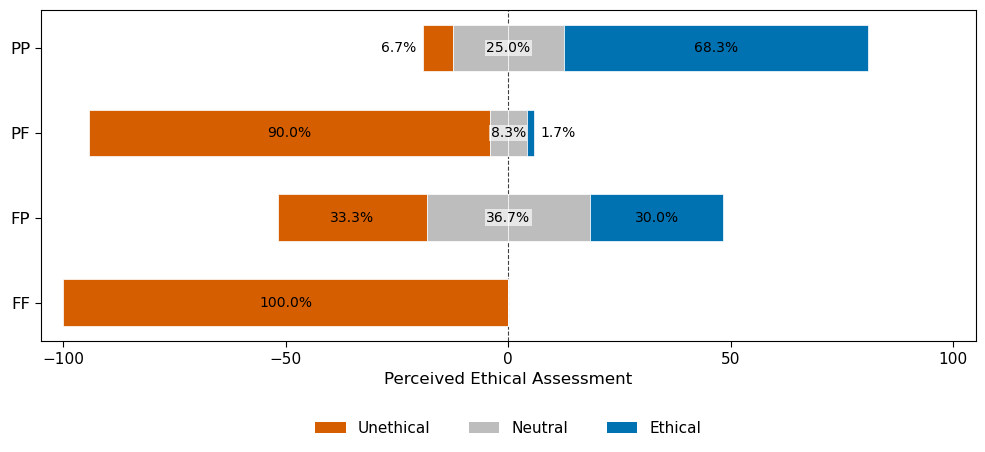

In [10]:
plot_df = (
    test_case_ethics_props
    .rename_axis("rating")
    .reset_index()
    .melt(
        id_vars="rating",
        var_name="TestCase",
        value_name="pct",
    )
)

RATING_ORDER = ["Unethical", "Neutral", "Ethical"]
testcase_order = ["PP", "PF", "FP", "FF"]

plot_df["TestCase"] = pd.Categorical(
    plot_df["TestCase"],
    categories=testcase_order,
    ordered=True,
)

plot_df["rating"] = pd.Categorical(
    plot_df["rating"],
    categories=RATING_ORDER,
    ordered=True,
)

plot_table = (
    plot_df
    .pivot(index="TestCase", columns="rating", values="pct")
    .reindex(testcase_order)
    .fillna(0)
)

unethical = plot_table["Unethical"].to_numpy()
neutral = plot_table["Neutral"].to_numpy()
ethical = plot_table["Ethical"].to_numpy()

y_pos = np.arange(len(testcase_order))

color_map = {
    "Unethical": "#D55E00",  # vermillion
    "Neutral": "#BDBDBD",    # gray
    "Ethical": "#0072B2",    # blue
}

fig, ax = plt.subplots(figsize=(11, 4.8))

bar_height = 0.55

ax.barh(
    y_pos,
    unethical,
    left=-(unethical + neutral / 2),
    height=bar_height,
    color=color_map["Unethical"],
    edgecolor="white",
    linewidth=0.5,
)

ax.barh(
    y_pos,
    neutral / 2,
    left=-neutral / 2,
    height=bar_height,
    color=color_map["Neutral"],
    edgecolor="white",
    linewidth=0.5,
)

ax.barh(
    y_pos,
    neutral / 2,
    left=0,
    height=bar_height,
    color=color_map["Neutral"],
    edgecolor="white",
    linewidth=0.5,
)

# Ethical responses.
ax.barh(
    y_pos,
    ethical,
    left=neutral / 2,
    height=bar_height,
    color=color_map["Ethical"],
    edgecolor="white",
    linewidth=0.5,
)

for i, (u, n, e) in enumerate(zip(unethical, neutral, ethical)):

    # Unethical label
    if u > 0:
        x_u = -(n / 2 + u / 2)

        if u >= 8:
            ax.text(
                x_u,
                i,
                f"{u:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
            )
        else:
            ax.text(
                -(n / 2 + u) - 1.5,
                i,
                f"{u:.1f}%",
                ha="right",
                va="center",
                fontsize=10,
            )

    # Neutral label
    if n > 0:
        ax.text(
            0,
            i,
            f"{n:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.65,
                "pad": 1,
            },
        )

    if e > 0:
        x_e = n / 2 + e / 2

        if e >= 8:
            ax.text(
                x_e,
                i,
                f"{e:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
            )
        else:
            ax.text(
                n / 2 + e + 1.5,
                i,
                f"{e:.1f}%",
                ha="left",
                va="center",
                fontsize=10,
            )

ax.set_yticks(y_pos)
ax.set_yticklabels(testcase_order, fontsize=12)
ax.invert_yaxis()

ax.set_xlim(-105, 105)
ax.set_xticks([-100, -50, 0, 50, 100])
ax.tick_params(axis="x", labelsize=11)

ax.set_xlabel("Perceived Ethical Assessment", fontsize=12)
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
    alpha=0.75,
    zorder=0,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

ax.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=0.8,
)

ax.grid(False)
legend_handles = [
    Patch(
        facecolor=color_map["Unethical"],
        edgecolor="none",
        label="Unethical",
    ),
    Patch(
        facecolor=color_map["Neutral"],
        edgecolor="none",
        label="Neutral",
    ),
    Patch(
        facecolor=color_map["Ethical"],
        edgecolor="none",
        label="Ethical",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=2.0,
    columnspacing=2.5,
)

plt.subplots_adjust(
    left=0.13,
    right=0.98,
    top=0.97,
    bottom=0.28,
)

plt.show()

In [11]:
build_parallel_categories_figure(test_case_ethics_ratings).show()
build_sankey_figure(test_case_ethics_ratings).show()


# RQ2

What factors influence how participants perceive a self-driving car's behavior as ethically appropriate?


In [12]:
ROLE_COLUMN = "  You are a  "
AGE_COLUMN = "Age"
PROGRAMMING_EXPERIENCE_COLUMN = "Do you have any programming experience?"
TESTING_EXPERIENCE_COLUMN = "Do you have any experience with testing any system or application? "
DRIVING_EXPERIENCE_COLUMN = "How many years of driving experience do you have?"

EXPERIENCE_ORDER = ["None", "Less than one year", "1-2 years", "2-5 years", ">5 years"]
FACTOR_CONFIGS = [
    {
        "name": "Role",
        "column": ROLE_COLUMN,
        "order": [
            "Student",
            "PhD student",
            "Researcher",
            "Postdoctoral researcher",
            "Both Student and Professional",
            "Professional",
        ],
        "group_labels": ("Academic or mixed roles", "Professional"),
    },
    {
        "name": "Age",
        "column": AGE_COLUMN,
        "order": ["18-25", "26-30", "31-35", "36-40", "41-45", "46-50", "51-55", "56<"],
    },
    {
        "name": "Programming experience",
        "column": PROGRAMMING_EXPERIENCE_COLUMN,
        "order": EXPERIENCE_ORDER,
    },
    {
        "name": "Testing experience",
        "column": TESTING_EXPERIENCE_COLUMN,
        "order": EXPERIENCE_ORDER,
    },
    {
        "name": "Driving experience",
        "column": DRIVING_EXPERIENCE_COLUMN,
        "order": EXPERIENCE_ORDER,
        "include_median_in": "high",
        "missing_label": "None",
        "group_labels": ("0-5 years", ">5 years"),
    },
]

factor_analyses = [analyse_ordinal_factor(SURVEY, config) for config in FACTOR_CONFIGS]
factor_groups = [
    (
        analysis["name"],
        [
            (analysis["low_label"], analysis["low_ratings"]),
            (analysis["high_label"], analysis["high_ratings"]),
        ],
    )
    for analysis in factor_analyses
]

factor_summary = pd.DataFrame(
    {
        "Factor": analysis["name"],
        "Median bin": analysis["median"],
        "Low group": analysis["low_label"],
        "Low n": analysis["low_n"],
        "High group": analysis["high_label"],
        "High n": analysis["high_n"],
    }
    for analysis in factor_analyses
)
display(factor_summary)


,Factor,Median bin,Low group,Low n,High group,High n
0,Role,Both Student and Professional,Academic or mixed roles,34,Professional,26
1,Age,26-30,<= 26-30,32,> 26-30,28
2,Programming experience,2-5 years,<= 2-5 years,32,> 2-5 years,28
3,Testing experience,1-2 years,<= 1-2 years,38,> 1-2 years,22
4,Driving experience,>5 years,0-5 years,24,>5 years,36


In [13]:
for analysis in factor_analyses:
    show_factor_analysis(analysis)


Role: median bin = Both Student and Professional | Academic or mixed roles n = 34 | Professional n = 26


,test_case,test_statistic,p_value,decision
0,PP,410.0,0.564511,not significant (fail to reject H0)
1,PF,461.0,0.595673,not significant (fail to reject H0)
2,FP,466.0,0.709712,not significant (fail to reject H0)
3,FF,442.0,1.000000,not significant (fail to reject H0)


,test_case,n_low,n_high,A12
0,PP,34,26,0.463801
1,PF,34,26,0.521493
2,FP,34,26,0.527149
3,FF,34,26,0.500000


Age: median bin = 26-30 | <= 26-30 n = 32 | > 26-30 n = 28


,test_case,test_statistic,p_value,decision
0,FP,553.0,0.100141,not significant (fail to reject H0)
1,PF,473.0,0.485172,not significant (fail to reject H0)
2,PP,425.0,0.682706,not significant (fail to reject H0)
3,FF,448.0,1.000000,not significant (fail to reject H0)


...

,test_case,test_statistic,p_value,decision
0,PP,358.5,0.267131,not significant (fail to reject H0)
1,FP,464.0,0.458616,not significant (fail to reject H0)
2,PF,395.5,0.516412,not significant (fail to reject H0)
3,FF,418.0,1.000000,not significant (fail to reject H0)


,test_case,n_low,n_high,A12
0,PP,38,22,0.428828
1,PF,38,22,0.473086
2,FP,38,22,0.555024
3,FF,38,22,0.500000


Driving experience: median bin = >5 years | 0-5 years n = 24 | >5 years n = 36


,test_case,test_statistic,p_value,decision
0,PP,370.5,0.259080,not significant (fail to reject H0)
1,FP,368.0,0.308952,not significant (fail to reject H0)
2,PF,451.5,0.581465,not significant (fail to reject H0)
3,FF,432.0,1.000000,not significant (fail to reject H0)


,test_case,n_low,n_high,A12
0,PP,24,36,0.428819
1,PF,24,36,0.522569
2,FP,24,36,0.425926
3,FF,24,36,0.500000


## RQ2 Grouped Summary


In [14]:
grouped_figures = grouped_stacked_by_test_case(factor_groups=factor_groups, use_percent=True)

for test_case in TEST_CASE_ORDER:
    grouped_figures[test_case].show()

factor_rating_table = build_factor_rating_table(factor_groups)
display(factor_rating_table)


,Test case,Factor,Group,N,Unethical,Neutral,Ethical
0,PP,Role,Academic or mixed roles,34,2 (5.9%),10 (29.4%),22 (64.7%)
1,PP,Role,Professional,26,2 (7.7%),5 (19.2%),19 (73.1%)
2,PP,Age,<= 26-30,32,2 (6.2%),9 (28.1%),21 (65.6%)
3,PP,Age,> 26-30,28,2 (7.1%),6 (21.4%),20 (71.4%)
4,PP,Programming experience,<= 2-5 years,32,2 (6.2%),10 (31.2%),20 (62.5%)
5,PP,Programming experience,> 2-5 years,28,2 (7.1%),5 (17.9%),21 (75.0%)
6,PP,Testing experience,<= 1-2 years,38,3 (7.9%),11 (28.9%),24 (63.2%)
7,PP,Testing experience,> 1-2 years,22,1 (4.5%),4 (18.2%),17 (77.3%)
8,PP,Driving experience,0-5 years,24,1 (4.2%),9 (37.5%),14 (58.3%)
9,PP,Driving experience,>5 years,36,3 (8.3%),6 (16.7%),27 (75.0%)


# RQ3

To what extent is a self-driving car's safe behavior perceived as aligned with its ethical behavior?


,Answer,Count,Percentage
0,Yes – Safe behavior and ethical behavior alway...,15,25.000000
1,No – A car can be safe but still act unethical...,38,63.333333
2,Unsure,7,11.666667


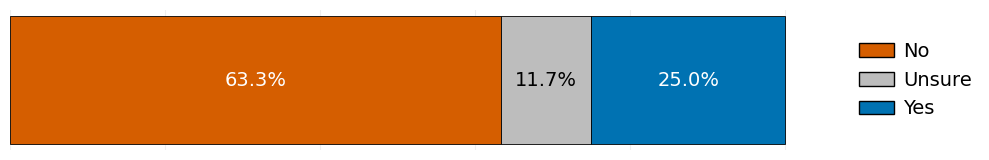

In [15]:
safe_ethical_distribution = response_distribution(
    SURVEY,
    SAFE_ETHICAL_COLUMN,
    SAFE_ETHICAL_ORDER,
)

display(safe_ethical_distribution)


safe_ethical_bar_distribution = response_distribution(
    SURVEY,
    SAFE_ETHICAL_COLUMN,
    SAFE_ETHICAL_BAR_ORDER,
)

fig, ax = plot_single_stacked_response_bar(
    safe_ethical_bar_distribution
)

plt.show()